In [52]:
from sklearn.datasets import make_classification
import numpy as np 
X,Y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=20)

In [54]:
X.shape
# Y.shape

(100, 2)

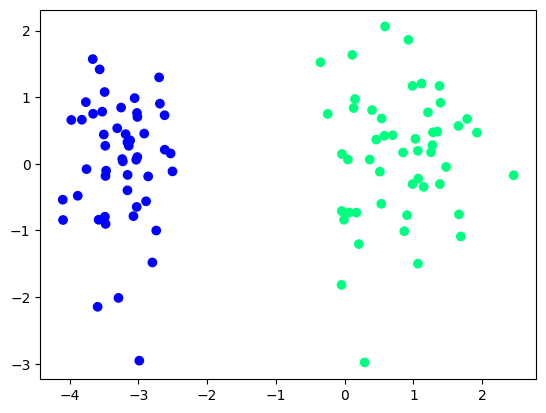

In [55]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=Y,cmap='winter')

In [56]:
def step_function(x):
    return 1 if x>0 else 0

In [57]:
def perceptron(X,Y):
    # insert a column of 1's in the beginning of X
    X = np.insert(X, 0, 1, axis=1)
    # create a weight vector of size 3 (2 for the features and 1 for the bias)
    weights=np.ones(X.shape[1])
    # initialize learning rate
    lr=0.01
    for i in range(1000):
        # select a random index from the dataset
        j=np.random.randint(0,100)
        # doing the dot product of the selected row and the weight vector
        y_hat=step_function(np.dot(X[j],weights))
        weights=weights+lr*(Y[j]-y_hat)*X[j]
    # returning intercept and the coefficients
    return weights[0],weights[1:]

In [58]:
intercept_,coef_=perceptron(X,Y)
print(coef_)
print(intercept_)

[1.03831978 0.49183863]
1.1900000000000002


In [59]:
m=-coef_[0]/coef_[1]
c=-intercept_/coef_[1]
print(m,c)

-2.111098498775524 -2.4194927708243896


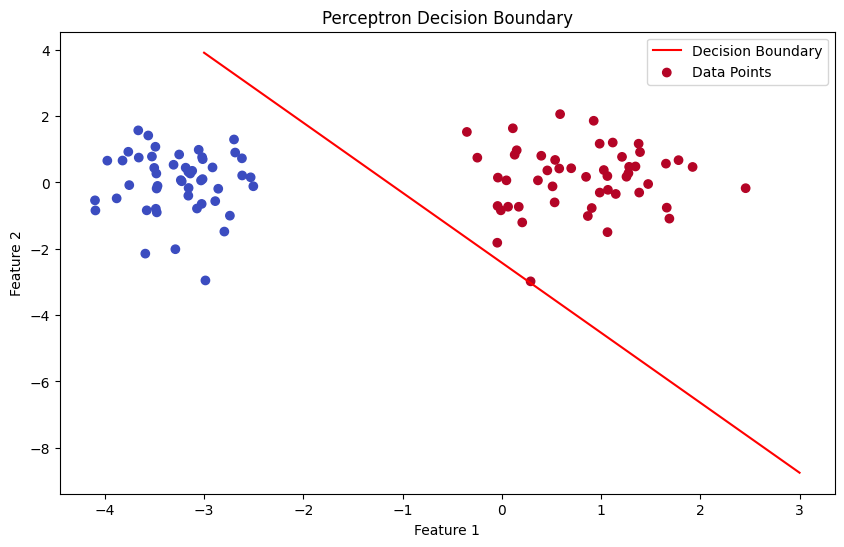

In [60]:
x1_input=np.linspace(-3,3,100)
y1_input=m*x1_input+c
plt.figure(figsize=(10,6))
plt.plot(x1_input, y1_input, color='red', label='Decision Boundary')
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', label='Data Points')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary')
plt.legend()
plt.show()

In [13]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [62]:
def perceptron(X,Y):
    # insert a column of 1's in the beginning of X
    X = np.insert(X, 0, 1, axis=1)
    # create a weight vector of size 3 (2 for the features and 1 for the bias)
    weights=np.ones(X.shape[1])
    # initialize learning rate
    lr=0.01
    for i in range(1000):
        # select a random index from the dataset
        j=np.random.randint(0,100)
        # doing the dot product of the selected row and the weight vector
        y_hat=sigmoid(np.dot(X[j],weights))
        weights=weights+lr*(Y[j]-y_hat)*X[j]
        # returning intercept and the coefficients
    return weights[0],weights[1:]

In [63]:
intercept_,coef_=perceptron(X,Y)
print(coef_)
print(intercept_)

[1.79792902 0.52473759]
1.4261372557074408


In [64]:
m=-coef_[0]/coef_[1]
c=-intercept_/coef_[1]
print(m,c)

-3.426339291678734 -2.7178103659255672


In [65]:
from sklearn.linear_model import LogisticRegression


# Train
model = LogisticRegression()
model.fit(X,Y)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
x2_input=np.linspace(-3,3,100)
y2_input=-(model.coef_[0][0]*x2_input+model.intercept_)/model.coef_[0][1]

Intercept: [3.13571596]
Coefficients: [[2.36679363 0.02300492]]


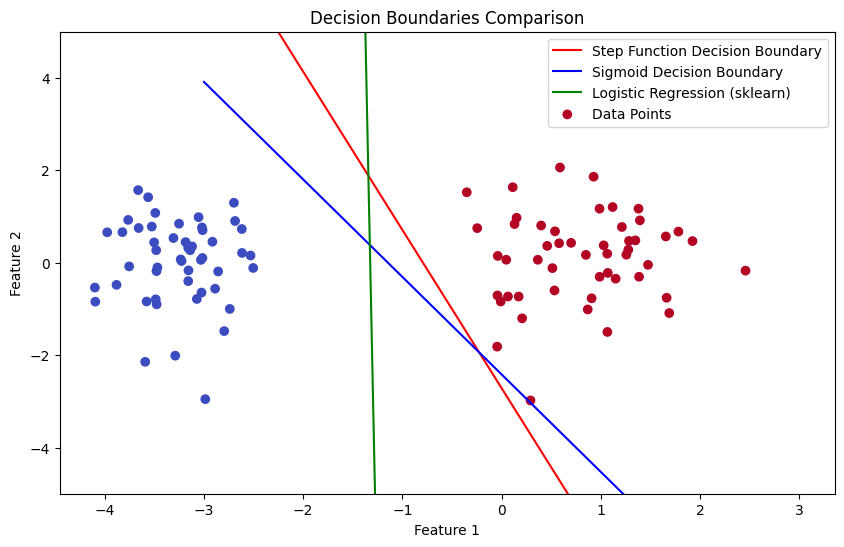

In [70]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input+c
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', label='Step Function Decision Boundary')
plt.plot(x1_input, y1_input, color='blue', label='Sigmoid Decision Boundary')
plt.plot(x2_input, y2_input, color='green', label='Logistic Regression (sklearn)')
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', label='Data Points')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.ylim(-5, 5)
plt.title('Decision Boundaries Comparison')
plt.legend()
plt.show()

In [1]:
from sklearn.datasets import make_classification
import numpy as np 
X,Y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=20)

In [3]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(penalty=None,solver='sag')
model.fit(X,Y)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [5.7546542]
Coefficients: [[4.78616417 0.20947978]]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [4]:
m1=-model.coef_[0][0]/model.coef_[0][1]
c1=-model.intercept_/model.coef_[0][1]
print(m1,c1)

-22.847857331649582 [-27.47116763]


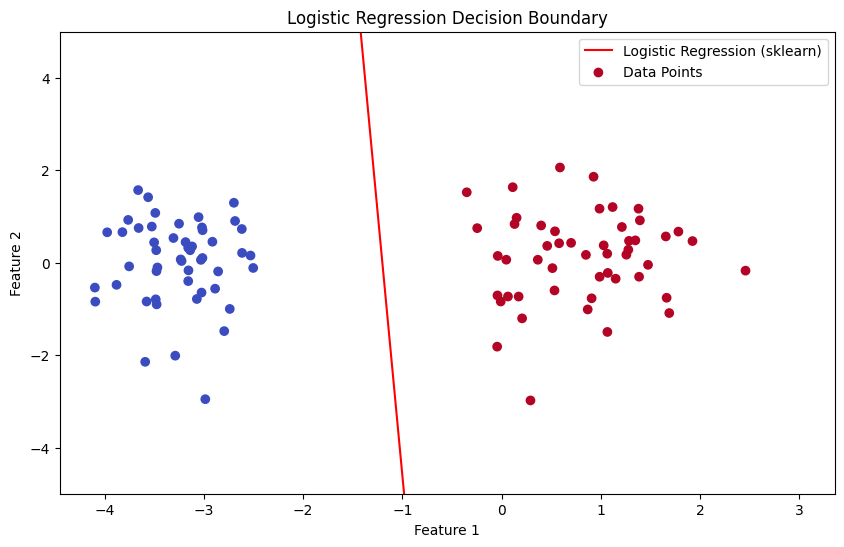

In [10]:
import matplotlib.pyplot as plt
x_input=np.linspace(-3,3,100)
y_input=m1*x_input+c1
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', label='Logistic Regression (sklearn)')
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', label='Data Points')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.ylim(-5, 5)
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

In [1]:
def gd(X,Y):
    # insert a column of 1's in the beginning of X
    X = np.insert(X, 0, 1, axis=1)
    # create a weight vector of size 3 (2 for the features and 1 for the bias)
    weights=np.ones(X.shape[1])
    # initialize learning rate
    lr=0.01
    for i in range(1000):
        y_hat=sigmoid(np.dot(X,weights))
        weights=weights+lr*(Y-y_hat).dot(X)
        # returning intercept and the coefficients
    return weights[1:],weights[0]
    

In [2]:
coef_,intercept_=gd(X,Y)
print(coef_)
print(intercept_)

NameError: name 'X' is not defined

In [20]:
m2=-(coef_[0]/coef_[1])
c2=-intercept_/coef_[1]
print(m2,c2)

-22.844609149042824 -27.537938181120094


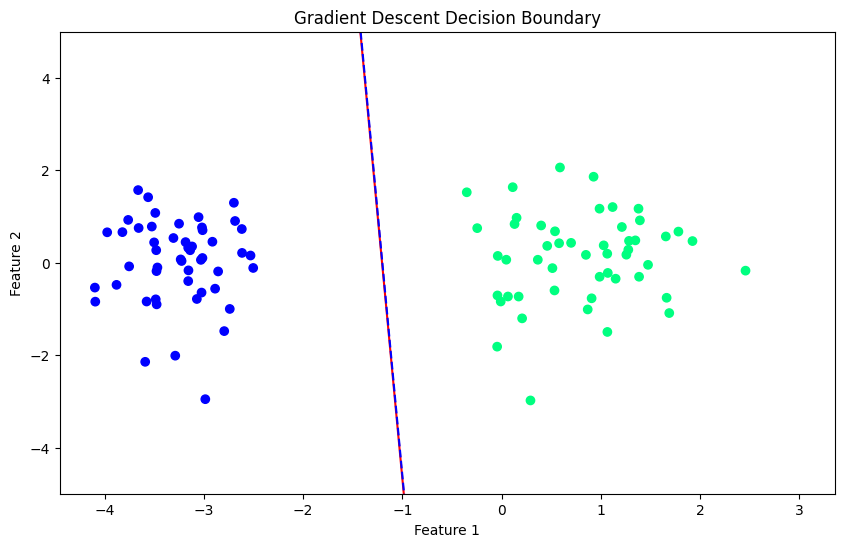

In [ ]:
x1_input=np.linspace(-3,3,100)
y1_input=m2*x1_input+c2
plt.figure(figsize=(10, 6))
plt.scatter(X[:,0], X[:,1], c=Y,cmap='winter')
plt.plot(x1_input, y1_input, color='red', label='Gradient Descent Decision Boundary')
plt.plot(x_input, y_input, color='blue', linestyle='--', label='Logistic Regression (sklearn)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.ylim(-5, 5)
plt.title('Gradient Descent Decision Boundary')
plt.show()

### Softmax Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
# encoding the target variable
encoder=LabelEncoder()
df['species']=encoder.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df=df[['sepal_length','petal_length','species']]
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [10]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]
print(X.shape, Y.shape)

(150, 2) (150,)


In [11]:
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X,Y,test_size=0.2,random_state=41)
print(X_Train.shape, Y_Train.shape)
print(X_Test.shape, Y_Test.shape)

(120, 2) (120,)
(30, 2) (30,)


In [13]:
model=LogisticRegression()
model.fit(X_Train, Y_Train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
y_pred=model.predict(X_Test)
y_pred

array([2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 0, 0, 1, 0, 2, 0, 2, 0, 0, 1, 2,
       0, 0, 1, 1, 1, 1, 0, 1])

In [16]:
accuracy_score(Y_Test, y_pred)

0.9666666666666667

In [17]:
pd.DataFrame(confusion_matrix(Y_Test, y_pred))

,0,1,2
0,9,0,0
1,0,10,1
2,0,0,10


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Logistic Regression Decision Boundary')

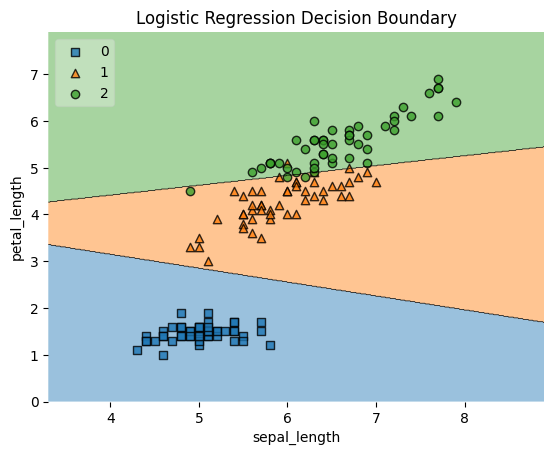

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values, Y.values, clf=model, legend=2)
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.title('Logistic Regression Decision Boundary')